<a href="https://colab.research.google.com/github/NinhHTK/ML-CPV-Documents/blob/main/Histogram_Equalization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

image_path = 'anhcpv.jpg'

img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
assert img is not None, f"File {image_path} could not be read, please ensure it is uploaded correctly."

hist, bins = np.histogram(img.flatten(), 256, [0, 256])
cdf = hist.cumsum()

/tmp/ipykernel_4038/2009988578.py:5: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img.flatten(), 256, [0, 256], color='r')


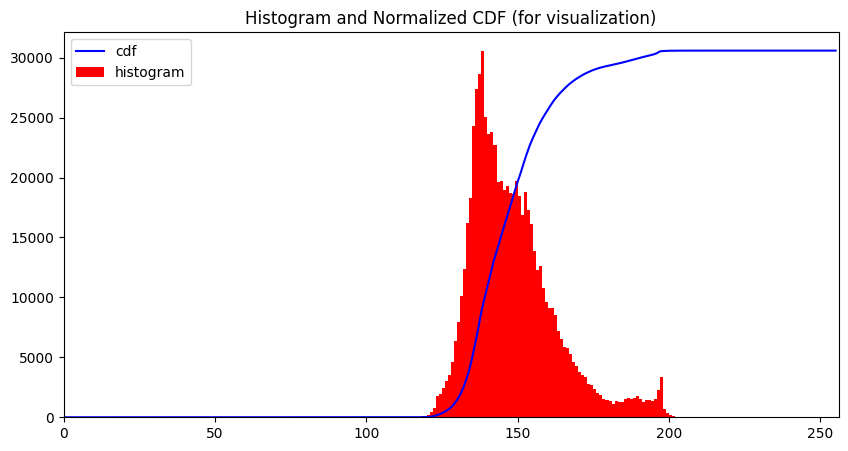

In [13]:
cdf_normalized = cdf * hist.max() / cdf.max()

plt.figure(figsize=(10, 5))
plt.plot(cdf_normalized, color='b')
plt.hist(img.flatten(), 256, [0, 256], color='r')
plt.xlim([0, 256])
plt.legend(('cdf', 'histogram'), loc='upper left')
plt.title('Histogram and Normalized CDF (for visualization)')
plt.show()

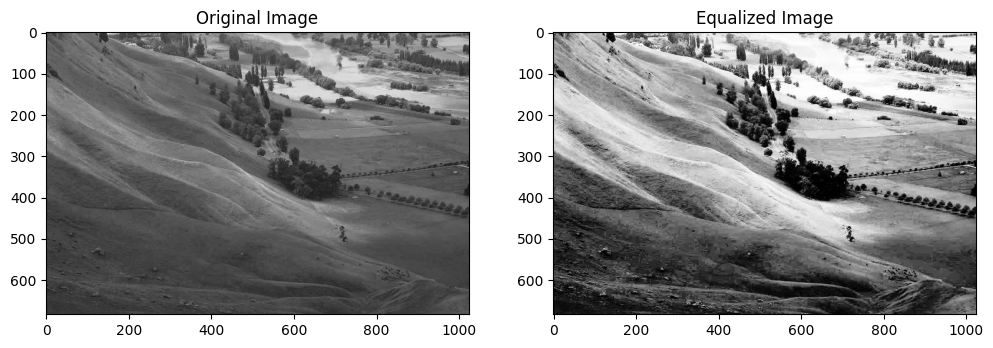

In [14]:
masked_cdf = np.ma.masked_equal(cdf, 0)

normalized_masked_cdf = (masked_cdf - masked_cdf.min()) * 255 / (masked_cdf.max() - masked_cdf.min())

normalized_cdf = np.ma.filled(normalized_masked_cdf, 0).astype('uint8')

img_hist_equalization = normalized_cdf[img]

f, axis_array = plt.subplots(1, 2, figsize=(12, 8))
axis_array[0].imshow(img, cmap='gray')
axis_array[0].set_title('Original Image')
axis_array[1].imshow(img_hist_equalization, cmap='gray')
axis_array[1].set_title('Equalized Image')
plt.show()

Câu hỏi kiểm tra (Answers)

1. **Tại sao cần mask các giá trị 0 trong CDF trước khi chuẩn hóa?**
    Chúng ta cần mask các giá trị 0 để tránh việc chia cho 0 trong công thức chuẩn hóa và để đảm bảo rằng các pixel không xuất hiện trong ảnh gốc không ảnh hưởng đến việc tính toán giá trị độ sáng tối thiểu mới.

2. **Kết quả ảnh sau khi cân bằng histogram trông như thế nào so với ảnh gốc? Độ tương phản thay đổi ra sao?**
    Ảnh sau khi cân bằng thường trông rõ nét hơn. Độ tương phản (contrast) tăng lên đáng kể vì các dải giá trị pixel được trải đều ra toàn bộ dải từ 0 đến 255.

3. **Kỹ thuật này có phù hợp với ảnh màu (3 kênh BGR) không? Giải thích ngắn gọn.**
    Không nên áp dụng trực tiếp lên từng kênh màu (B, G, R) riêng lẻ vì sẽ làm sai lệch màu sắc (color imbalance). Đối với ảnh màu, người ta thường chuyển sang không gian màu như YUV hoặc HSV, áp dụng cân bằng histogram lên kênh độ sáng (Y hoặc V), sau đó mới chuyển ngược lại BGR.